<a href="https://colab.research.google.com/github/aydanh2005/DLBDSMLUSL01_Mental_Health_Clustering_Aydan/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22DLBDSMLUSL01_Mental_Health_Clustering_Aydan%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Load file
df = pd.read_csv('/content/mental-health-in-tech-2016_20161114.csv')

# Select exact columns
features = [
    'What is your age?',
    'What is your gender?',
    'What country do you live in?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'How many employees does your company or organization have?'
]

# Clean copy
df_clean = df[features].dropna().copy()

# Encode text columns
le = LabelEncoder()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Scale data
X = StandardScaler().fit_transform(df_clean)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Results
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))
print("Clean data shape:", df_clean.shape)

Explained variance ratio: [0.24277018 0.20505052]
Total explained variance: 0.4478206975831698
Clean data shape: (1143, 5)


In [21]:
import pandas as pd

df = pd.read_csv('/content/mental-health-in-tech-2016_20161114.csv')
print(df.shape)

(1433, 63)


In [17]:
import os
print(os.listdir('/content'))

['.config', 'mental-heath-in-tech-2016_20161114.csv', 'sample_data']


In [16]:
print("df exists:", "df" in globals())
print("df_clean exists:", "df_clean" in globals())
print("X_scaled exists:", "X_scaled" in globals())
print("pca exists:", "pca" in globals())

df exists: True
df_clean exists: False
X_scaled exists: False
pca exists: True


In [40]:
cluster_summary = df_clean.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         What is your age?  What is your gender?  \
Cluster                                            
0                31.623632              4.472648   
1                34.292763              2.743421   
2                32.529617              2.822300   
3                38.217848              2.629921   

         What country do you live in?  \
Cluster                                 
0                           44.091904   
1                           40.075658   
2                           39.888502   
3                           42.606299   

         Have you ever sought treatment for a mental health issue from a mental health professional?  \
Cluster                                                                                                
0                                                      1.0                                             
1                                                      0.0                                             
2                       

In [39]:
from sklearn.preprocessing import StandardScaler

features = [
    'What is your age?',
    'What is your gender?',
    'What country do you live in?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'How many employees does your company or organization have?'
]

X = df_clean[features]
X_scaled = StandardScaler().fit_transform(X)

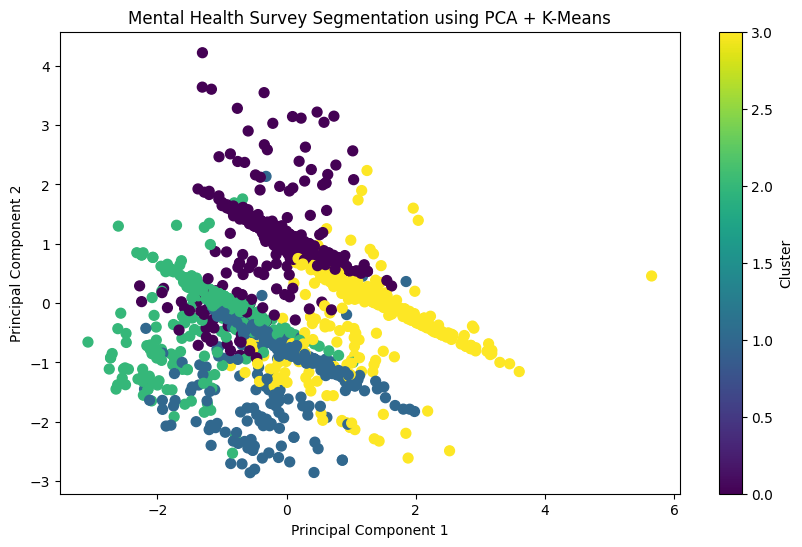

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_clean['Cluster'], cmap='viridis', s=50)

plt.title("Mental Health Survey Segmentation using PCA + K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(df_clean['Cluster'].value_counts())
df_clean.head()

Cluster
0    457
3    381
1    304
2    287
Name: count, dtype: int64


,What is your age?,What is your gender?,What country do you live in?,Have you ever sought treatment for a mental health issue from a mental health professional?,How many employees does your company or organization have?,Cluster
0,39,2,49,0,2,2
1,29,2,50,1,4,0
2,38,34,49,1,4,0
3,43,2,49,1,6,3
4,43,1,50,1,4,3


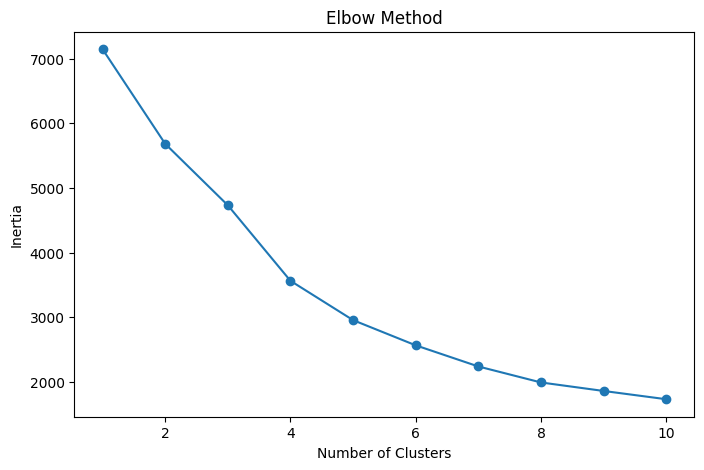

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# Try cluster numbers 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow chart
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale data
X_scaled = scaler.fit_transform(df_clean)

# Show shape
print(X_scaled.shape)
print(X_scaled[:5])

(1429, 5)
[[ 0.58933289 -0.18576567  0.49109994 -1.19077105 -0.73698835]
 [-0.62118414 -0.18576567  0.56122903  0.839792    0.29551788]
 [ 0.46828118  4.4510753   0.49109994  0.839792    0.29551788]
 [ 1.07353969 -0.18576567  0.49109994  0.839792    1.32802411]
 [ 1.07353969 -0.33066695  0.56122903  0.839792    0.29551788]]


In [28]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode each text column
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = le.fit_transform(df_clean[col])

# Show result
print(df_clean.head())
print(df_clean.dtypes)

   What is your age?  What is your gender?  What country do you live in?  \
0                 39                     2                            49   
1                 29                     2                            50   
2                 38                    34                            49   
3                 43                     2                            49   
4                 43                     1                            50   

   Have you ever sought treatment for a mental health issue from a mental health professional?  \
0                                                  0                                             
1                                                  1                                             
2                                                  1                                             
3                                                  1                                             
4                                                  1 

In [27]:
# Clean age: keep realistic ages only (18 to 100)
df_clean = df_clean[(df_clean['What is your age?'] >= 18) &
                    (df_clean['What is your age?'] <= 100)]

# Clean gender text
df_clean['What is your gender?'] = df_clean['What is your gender?'].str.lower()

df_clean['What is your gender?'] = df_clean['What is your gender?'].replace({
    'male': 'Male',
    'm': 'Male',
    'man': 'Male',
    'female': 'Female',
    'f': 'Female',
    'woman': 'Female'
})

# Fill missing gender with Unknown
df_clean['What is your gender?'] = df_clean['What is your gender?'].fillna('Unknown')

# Fill missing company size with Unknown
df_clean['How many employees does your company or organization have?'] = \
df_clean['How many employees does your company or organization have?'].fillna('Unknown')

# Check result
print(df_clean.shape)
print(df_clean['What is your gender?'].value_counts())

(1429, 5)
What is your gender?
Male                                                                                                                                                             1026
Female                                                                                                                                                            316
male                                                                                                                                                               13
female                                                                                                                                                             12
non-binary                                                                                                                                                          4
cis male                                                                                                                                   

In [ ]:
print(df_clean.isnull().sum())

In [26]:
# Select key columns for first cleaning
cols = [
    'What is your age?',
    'What is your gender?',
    'What country do you live in?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'How many employees does your company or organization have?'
]

df_clean = df_clean[cols].copy()
print(df_clean.head())
print(df_clean.shape)

   What is your age? What is your gender? What country do you live in?  \
0                 39                 Male               United Kingdom   
1                 29                 male     United States of America   
2                 38                Male                United Kingdom   
3                 43                 male               United Kingdom   
4                 43               Female     United States of America   

   Have you ever sought treatment for a mental health issue from a mental health professional?  \
0                                                  0                                             
1                                                  1                                             
2                                                  1                                             
3                                                  1                                             
4                                                  1             

In [25]:
# Make a working copy
df_clean = df.copy()

print("Original shape:", df.shape)
print("Copy shape:", df_clean.shape)

Original shape: (1433, 63)
Copy shape: (1433, 63)


In [23]:
# Shape
print("Shape:", df.shape)

# Missing values
print("\nTop Missing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Age statistics
print("\nAge Statistics:")
print(df['What is your age?'].describe())

# Top gender responses
print("\nTop Gender Responses:")
print(df['What is your gender?'].value_counts().head(10))

# Top countries
print("\nTop Countries:")
print(df['What country do you live in?'].value_counts().head(10))

Shape: (1433, 63)

Top Missing Values:
If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?            1289
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?    1229
Is your primary role within your company related to tech/IT?                                                                            1170
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?                   1146
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?            1146
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?                  1146
If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negative

In [ ]:
for col in df.columns:
    print(col)

In [22]:
import pandas as pd
df = pd.read_csv('/content/mental-heath-in-tech-2016_20161114.csv')
print(df.shape)
df.head()

(1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
